In [5]:
import sys
sys.path.append('.')
# from configs import path, nit, threedigits, thresh
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import math
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
deltax = 40
deltay = 30
deltaxy = 27

In [7]:
dx=4
dy=4
manual_setting=1
Stokes = [
        'Q'
        ]

In [8]:
def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

In [9]:
# ra_list = ['3:31:54', '3:34:16', '3:33:21', '3:35:05', '3:31:19', '3:30:09', '3:28:40', '3:32:41', '3:34:01']
# dec_list = ['31:04:39', '31:12:10', '30:55:28', '30:47:04', '30:47:23', '30:32:53', '30:49:56', '30:20:11', '31:18:40']

ra_list = [
#     '3:30:24',
#     '3:32:53',
#     '3:32:19',
    '3:29:30'
]
dec_list = [
#     '31:47:07',
#     '31:43:25',
#     '31:45:16',
    '31:30:21'
]

ra_list = np.array(ra_list)
dec_list = np.array(dec_list)

In [10]:
RA=[]
DEC=[]
for i in range(ra_list.shape[0]):
    radec=ra_dec_to_degrees(ra_list[i], dec_list[i])
    RA.append(radec[0])
    DEC.append(radec[1])

print(RA)
print(DEC)

[52.375]
[31.50583333333333]


In [11]:
if manual_setting!=0:
    RA0=RA
    DEC0=DEC
else:
    with open("source_list_test_G17.dat", 'r') as SOURCES:
        RA0=np.double(SOURCES[1])
        DEC0=np.double(SOURCES[2])

In [12]:
for stokes in Stokes:
    fits_file = '../server/old'+'/Stokes'+stokes+'.fits'
    hdulist=fits.open(fits_file)
    img=hdulist[0].data
    wcs=WCS(hdulist[0].header)
    if stokes=='I':
        stok = 1
    if stokes=='Q':
        stok = 2
    if stokes=='U':
        stoke = 3        

    for ip in range(len(RA0)):
        sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]
        pixcrd2 = wcs.all_world2pix(sky1, 0) 
        print(pixcrd2)

        x0=int(pixcrd2[0][0]+0.5)
        y0=int(pixcrd2[0][1]+0.5)

        if (DEC0[ip]>=0):
            sourcename_RADEC="J%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
        else:  
            sourcename_RADEC="J%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

        spectrum_file="%s_box_%03d_%03d_%s.pro" % (sourcename_RADEC,dx,dy,stokes)

        OUT=open('../server/old/'+spectrum_file,"w")

        print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)

        print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)
        print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)
        print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)
        print("## Spectrum file: ",spectrum_file, file=OUT)
        print("##  ", file=OUT)

        box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]
        mean_spectrum=img[:,x0,y0]
        freq=np.copy(mean_spectrum)

        # Use the array flag to keep track of flagged channels
        flag=np.copy(mean_spectrum)*0.0

        flag[np.isnan(flag)]=0.0

        ispec=0
        for ispec in range(len(mean_spectrum)):
            # Get ferquency of channel:
            # I have to change th 4th index
            sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
            freq[ispec]=sky[0][2]

            # Average over the box:
            mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
            if (mean_spectrum[ispec]>1.E10):
                # If in here, found at least some pixels with BLANK vale 1.E30
                # Discard the whole channel. Set flag array value to 1.
                mean_spectrum[ispec]=0
                flag[ispec]=1.
            print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum[ispec],int(flag[ispec]+0.5)), file=OUT)


        OUT.close()

    rms=np.std(mean_spectrum)

    if (rms>0.002):
        print(sourcename_RADEC, rms)

[[ 2.95048495e+03  2.76908777e+03  1.94333024e+01 -2.00000000e+00]]
Pixel coordinates:  2950 2769 J052.375+31.505 J052.375+31.505_box_004_004_Q.pro


Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [13]:
for stokes in Stokes:
    
    fits_file ='../server/old/'+'/Stokes'+stokes+'.fits'
    hdulist=fits.open(fits_file)
    img=hdulist[0].data
    wcs=WCS(hdulist[0].header)
    
    if stokes=='I':
        stok = 1
    if stokes=='Q':
        stok = 2
    if stokes=='U':
        stok = 3        

    for ip in range(len(RA0)):
        sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]
        pixcrd2 = wcs.all_world2pix(sky1, 0) 
        print(pixcrd2)

        x0=int(pixcrd2[0][0]+0.5)
        y0=int(pixcrd2[0][1]+0.5)

        if (DEC0[ip]>=0):
            sourcename_RADEC="H%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
        else:  
            sourcename_RADEC="H%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

        spectrum_file = "%s_%s_%s_%s.pro" % (sourcename_RADEC, dx, dy, stokes)

        OUT=open('../server/old/'+spectrum_file,"w")

        print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)
        print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)
        print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)
        print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)
        print("## Spectrum file: ",spectrum_file, file=OUT)
        print("##  ", file=OUT)

        box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]
        mean_spectrum=img[:,x0,y0]
        freq=np.copy(mean_spectrum)
        

        # Use the array flag to keep track of flagged channels
        flag=np.copy(mean_spectrum)*0.0

        flag[np.isnan(flag)]=0.0

       
        for ispec in range(len(mean_spectrum)):
            # Get ferquency of channel:
            # I have to change th 4th index
            sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
            freq[ispec]=sky[0][2]

            # Average over the box:
            mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
            
            
            #Background
            background_1 = img[ispec,x0, (y0+deltay)]
            background_2 = img[ispec,x0, (y0-deltay)]
            background_3 = img[ispec,(x0+deltax), y0]
            background_4 = img[ispec,(x0-deltax), y0]
            background_5 = img[ispec,(x0+deltax), (y0+deltay)]
            background_6 = img[ispec,(x0+deltax), (y0-deltay)]
            background_7 = img[ispec,(x0-deltax), (y0-deltay)]
            background_8 = img[ispec,(x0-deltax), (y0+deltay)]
            print (f"Backgrounds:{background_1},{background_2},{background_3},{background_4},{background_5},{background_6},{background_7},{background_8}")
            
            diff = mean_spectrum[ispec]-[background_1,background_2,background_3,background_4,
                    background_5,background_6,background_7,background_8]
            
            mean_spectrum_reduced = np.median(diff)
            
            if (mean_spectrum[ispec]>1.E10):
                # If in here, found at least some pixels with BLANK vale 1.E30
                # Discard the whole channel. Set flag array value to 1.
                mean_spectrum[ispec]=0
                flag[ispec]=1.
            print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum_reduced,int(flag[ispec]+0.5)), file=OUT)


        OUT.close()

    rms=np.std(mean_spectrum)

    if (rms>0.002):
        print(sourcename_RADEC, rms)

[[ 2.95048495e+03  2.76908777e+03  1.94333024e+01 -2.00000000e+00]]
Pixel coordinates:  2950 2769 H052.375+31.505 H052.375+31.505_4_4_Q.pro
Backgrounds:0.00011088836618000641,-0.00021603083587251604,0.00015797458763699979,-0.00024421288981102407,0.0004457823233678937,-0.00012443105515558273,-0.00026450472068972886,0.0003473316610325128
Backgrounds:0.00011088836618000641,-0.00021603083587251604,0.00015797458763699979,-0.00024421288981102407,0.0004457823233678937,-0.00012443105515558273,-0.00026450472068972886,0.0003473316610325128
Backgrounds:0.00020965022849850357,-0.00020401964138727635,6.531758845085278e-05,-3.258809010731056e-05,0.00024603394558653235,-0.00012862443691119552,-0.00019714866357389838,0.00015611998969689012
Backgrounds:0.00018399620603304356,0.0002603834436740726,0.00012412553769536316,-0.0002961881982628256,0.0005655608838424087,-3.0804952984908596e-05,-0.0008863727562129498,-7.021595229161903e-05
Backgrounds:0.00020215639960952103,-4.4337062718113884e-05,0.0002853936

In [16]:
def setup_columns(pro_file, noise_value, lines_to_skip=5):
    with open (pro_file, 'r') as file:
        lines = file.read().splitlines()[lines_to_skip:]
        lines = [ 
           [l.strip() for l in line.split()]
           for line in lines
        ]
        lines = np.array(lines).transpose()
        
        freq = np.double(lines[0])
        print(f"freq shape: {freq.shape}")
        flux = np.double(lines[1])
        print(f"flux shape: {flux.shape}")
        flag = np.double(lines[2])
        print(f"flag shape: {flag.shape}")
        noise = np.copy(freq) * 0.0 + noise_value
    return(freq, flux, flag, noise)

In [17]:
original = setup_columns('../server/old/J052.375+31.505_box_004_004_Q.pro')
reduced_median = setup_columns('../server/old/H052.375+31.505_4_4_Q.pro')
# reduced_mean = setup_columns('../server/old/mean/H053.504+31.311_4_4_Q.pro')

TypeError: setup_columns() missing 1 required positional argument: 'noise_value'

In [11]:
plt.figure(figsize=(12,10))

<Figure size 864x720 with 0 Axes>

<Figure size 864x720 with 0 Axes>

In [12]:
plt.figure
plt.plot(original[0], original[1], label = 'original')
plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()

NameError: name 'original' is not defined

In [6]:
original = setup_columns('../server/J052.600+31.785_box_004_004_Q.pro')
reduced_median = setup_columns('../server/median/H052.600+31.785_4_4_Q.pro')
reduced_mean = setup_columns('../server/mean/H052.600+31.785_4_4_Q.pro')

freq shape: (70,)
flux shape: (70,)
freq shape: (70,)
flux shape: (70,)
freq shape: (70,)
flux shape: (70,)


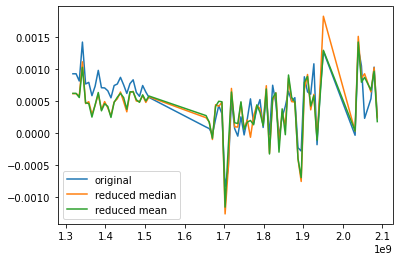

In [7]:
plt.figure
plt.plot(original[0], original[1], label = 'original')
plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()

In [18]:
original = setup_columns('../server/old/J052.375+31.505_box_004_004_Q.pro',9*1e-5, lines_to_skip=5)
# reduced_median = setup_columns('../server/median/H052.600+31.785_4_4_Q.pro')
reduced_mean = setup_columns('../server/old/H052.375+31.505_4_4_Q.pro',9*1e-5, lines_to_skip=5)

freq shape: (70,)
flux shape: (70,)
flag shape: (70,)
freq shape: (70,)
flux shape: (70,)
flag shape: (70,)


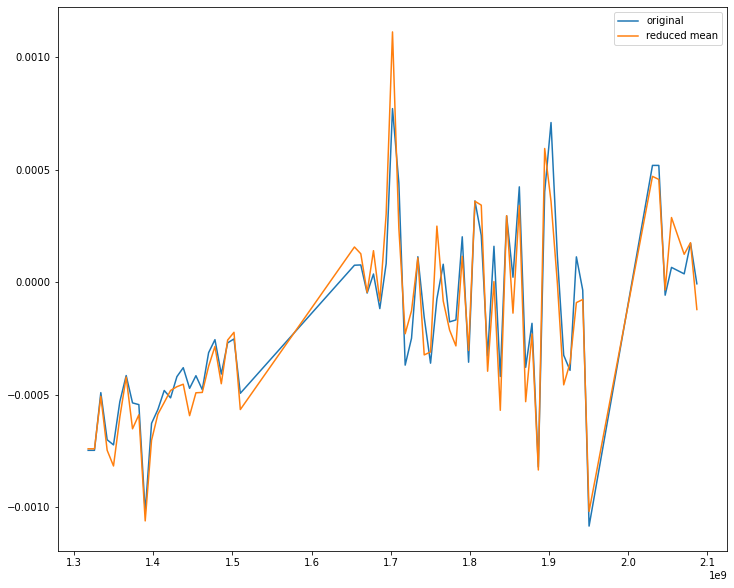

In [19]:
plt.figure(figsize=(12,10))
plt.plot(original[0], original[1], label = 'original')
# plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()

In [27]:
original = setup_columns('../server/moriginal/J053.079+31.754_box_004_004_Q.pro',9*1e-5, lines_to_skip=5)
# reduced_median = setup_columns('../server/median/H052.600+31.785_4_4_Q.pro')
reduced_mean = setup_columns('../server/mean/H053.079+31.754_4_4_Q.pro',9*1e-5, lines_to_skip=5)

freq shape: (70,)
flux shape: (70,)
flag shape: (70,)
freq shape: (70,)
flux shape: (70,)
flag shape: (70,)


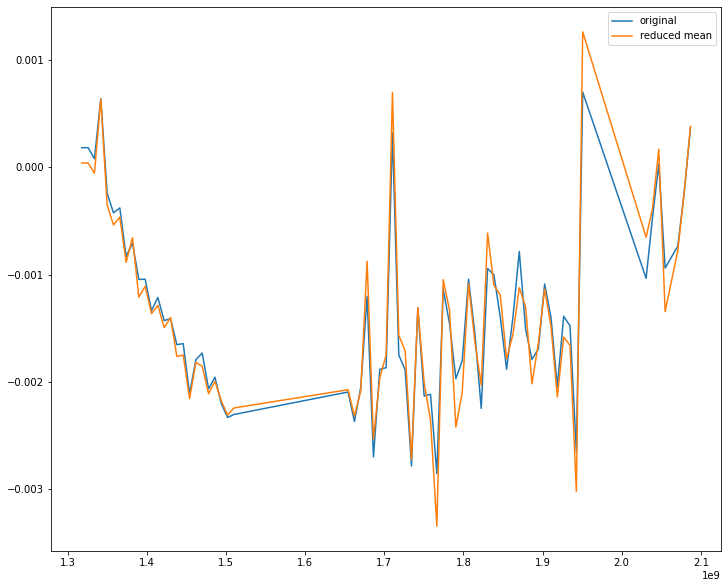

In [28]:
plt.figure(figsize=(12,10))
plt.plot(original[0], original[1], label = 'original')
# plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()

In [32]:
original = setup_columns('../server/moriginal/J052.375+31.505_box_004_004_Q.pro',9*1e-5, lines_to_skip=5)
# reduced_median = setup_columns('../server/median/H052.600+31.785_4_4_Q.pro')
reduced_mean = setup_columns('../server/mean/H052.375+31.505_4_4_Q.pro',9*1e-5, lines_to_skip=5)

freq shape: (70,)
flux shape: (70,)
flag shape: (70,)
freq shape: (70,)
flux shape: (70,)
flag shape: (70,)


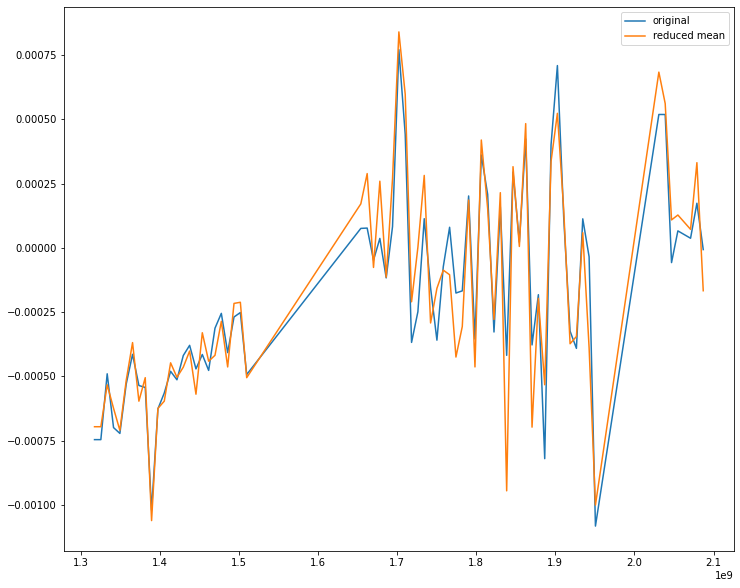

In [33]:
plt.figure(figsize=(12,10))
plt.plot(original[0], original[1], label = 'original')
# plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()

In [35]:
reduced =original[1]-reduced_mean[1]

In [36]:
reduced[9]

4.05273099999999e-05